# Lecture 19: Principal Component Analysis (PCA)

**F&W ECOL 458 — Environmental Data Science**

Reference: [scikit-learn PCA documentation](https://scikit-learn.org/stable/modules/decomposition.html#pca)

---

### Learning objectives

By the end of this lecture you should be able to:

1. Explain what PCA does and why it is useful for high-dimensional environmental data.
2. Interpret eigenvalues, explained variance, and scree plots.
3. Use PCA to visualize high-dimensional data in 2-D.
4. Apply PCA as a preprocessing step before classification.
5. Combine PCA with K-Means to visualize and interpret clusters.
6. Construct a biplot and interpret the loading vectors.


## A Motivating Example: Buying a Car

Before we get into the algorithm, let's start with a problem you might actually face.

Imagine you're shopping for a used car. You open a website and you're immediately overwhelmed: make, model, year, mileage, engine size, horsepower, torque, fuel type, transmission, number of owners, accident history, tire condition, color, seating capacity, trunk volume, infotainment system, safety rating...

That's easily **20+ features** per car. Scrolling through hundreds of listings, each with 20 columns, is paralyzing. Your brain can't compare all of those dimensions simultaneously.

So what do you actually do? You mentally **filter**. You think: "For my needs, what *really* matters is probably price, mileage, year, and fuel efficiency. The rest is noise — I can ignore trunk volume and infotainment for now."

**You just did PCA in your head.** You took a high-dimensional dataset (20+ features), identified the directions of variation that matter most, and compressed your decision to 3–4 key dimensions. PCA does exactly this — but mathematically and automatically.

### The book summary analogy

Another way to think about it: reading a 1,000-page book is a luxury that few can afford. Wouldn't it be nice to summarize the most important points in just 2–3 pages? You lose some detail in the process, but you get the big picture — and the big picture is usually what you need to make decisions.

PCA is that summarizer for your data. It reads the full "book" (all your features), figures out the main "plot lines" (the directions of maximum variance), and gives you a 2–3 page summary (a few principal components) that captures most of the story.


## 1. The Problem: Too Many Dimensions

Environmental datasets are often **high-dimensional**:

- A Landsat 8 pixel has **6 spectral bands** (Blue, Green, Red, NIR, SWIR1, SWIR2).
- A vegetation plot survey might record **50+ species**.
- A flux tower dataset might have **20+ meteorological and flux variables**.

This creates several problems:

- You **can't visualize** more than 2–3 dimensions at once.
- Many features are **correlated** (e.g., Red and Green bands move together; temperature and VPD are correlated).
- Some algorithms (KNN, K-Means) suffer from the **curse of dimensionality** — distances become meaningless in high-dimensional space.

**PCA solves this** by finding a new set of axes — called **principal components** — that capture the maximum amount of variance in the fewest dimensions. It's a way to compress data without losing much information.


## 2. The Key Insight: Variance = Information

Before we look at the mechanics of PCA, we need to understand one fundamental idea: **variance is information**. The more a feature varies across your dataset, the more useful it is for distinguishing between data points. The less it varies, the less it tells you.

### The guessing game

Suppose you and your friends are playing a guessing game. Three friends — Alex, Ben, and Chris — cover their faces, and you have to identify them **based solely on their height**.

| Person | Height (cm) |
|---|---|
| Alex | 145 |
| Ben | 160 |
| Chris | 185 |

Easy! The heights vary a lot (high variance), so you can tell them apart immediately. Alex is the short one, Chris is the tall one, Ben is in the middle.


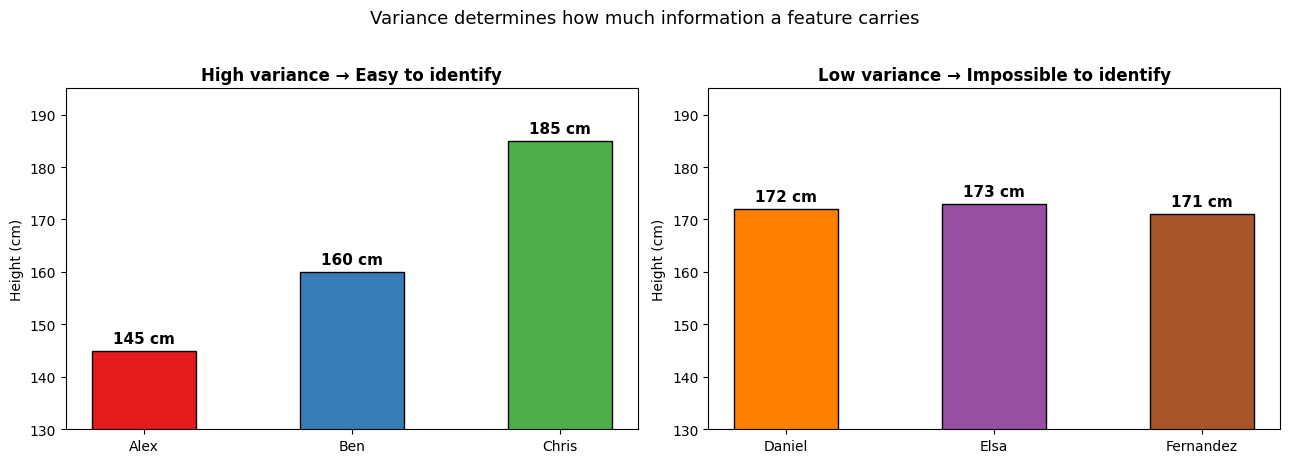

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── High variance: easy to tell apart ──
names_hv = ['Alex', 'Ben', 'Chris']
heights_hv = [145, 160, 185]
colors_hv = ['#e41a1c', '#377eb8', '#4daf4a']

axes[0].bar(names_hv, heights_hv, color=colors_hv, width=0.5, edgecolor='k')
axes[0].set_ylabel('Height (cm)')
axes[0].set_title('High variance → Easy to identify', fontweight='bold')
axes[0].set_ylim(130, 195)
for i, h in enumerate(heights_hv):
    axes[0].text(i, h + 1.5, f'{h} cm', ha='center', fontsize=11, fontweight='bold')

# ── Low variance: impossible to tell apart ──
names_lv = ['Daniel', 'Elsa', 'Fernandez']
heights_lv = [172, 173, 171]

axes[1].bar(names_lv, heights_lv, color=['#ff7f00', '#984ea3', '#a65628'], width=0.5, edgecolor='k')
axes[1].set_ylabel('Height (cm)')
axes[1].set_title('Low variance → Impossible to identify', fontweight='bold')
axes[1].set_ylim(130, 195)
for i, h in enumerate(heights_lv):
    axes[1].text(i, h + 1.5, f'{h} cm', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Variance determines how much information a feature carries', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Now try a different group of friends — Daniel (172 cm), Elsa (173 cm), and Fernandez (171 cm). Their heights are almost identical (low variance). You can't tell them apart at all! The height feature carries almost **no information** for this group.

**This is PCA's guiding principle:** features with high variance carry useful information; features with low variance are mostly noise. PCA finds the directions in your data that have the **maximum variance** — those are the principal components.

### What if two features have equal variance?

Now suppose you know both height **and** weight for Alex, Ben, and Chris:

| Person | Height (cm) | Weight (kg) |
|---|---|---|
| Alex | 145 | 60 |
| Ben | 160 | 67 |
| Chris | 185 | 88 |

Height has high variance, weight has some variance too. You'd naturally use both. But what if the variances were exactly equal? Could you drop one and keep the other? Not safely — you'd lose half the information.

Here's where PCA gets clever. Instead of choosing one feature to keep and one to throw away, PCA **combines** them. It creates a new axis — a weighted mixture of height and weight — that captures more variance than either original feature alone.


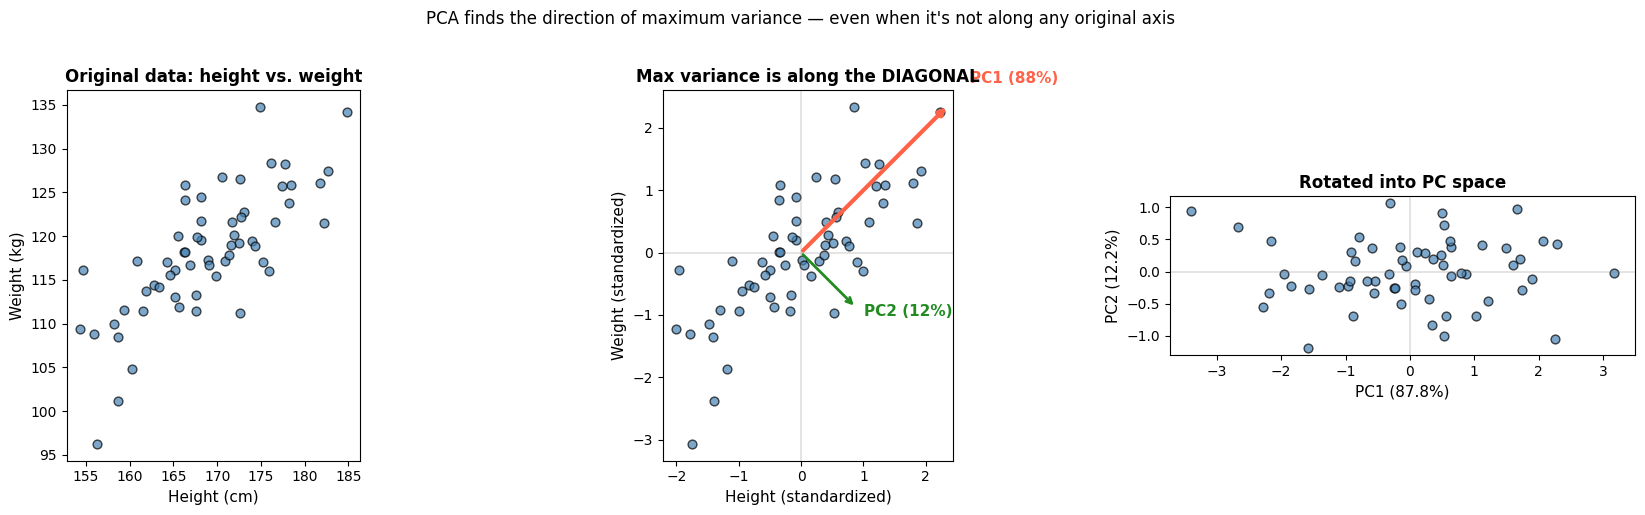

PC1 captures 87.8% of variance — by combining height and weight
PC2 captures 12.2% — we could safely drop it


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Simulate height and weight with equal variance ──
np.random.seed(42)
n = 60
height = np.random.normal(170, 8, n)
weight = 0.7 * height + np.random.normal(0, 5, n)  # correlated

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: Original data — which axis has more variance?
axes[0].scatter(height, weight, s=40, alpha=0.7, color='steelblue', edgecolors='k')
axes[0].set_xlabel('Height (cm)', fontsize=11)
axes[0].set_ylabel('Weight (kg)', fontsize=11)
axes[0].set_title('Original data: height vs. weight', fontweight='bold')
axes[0].set_aspect('equal')

# Panel 2: Show that maximum variance is along the diagonal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = np.column_stack([height, weight])
X_sc = StandardScaler().fit_transform(X)
pca = PCA(n_components=2).fit(X_sc)

axes[1].scatter(X_sc[:, 0], X_sc[:, 1], s=40, alpha=0.7, color='steelblue', edgecolors='k')
mean = [0, 0]
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    length = np.sqrt(var) * 2.5
    color = 'tomato' if i == 0 else 'forestgreen'
    lw = 3 if i == 0 else 2
    axes[1].annotate('', xy=[comp[0]*length, comp[1]*length], xytext=[0, 0],
                     arrowprops=dict(arrowstyle='->', color=color, linewidth=lw))
    label = f'PC{i+1} ({pca.explained_variance_ratio_[i]:.0%})'
    axes[1].text(comp[0]*length*1.15, comp[1]*length*1.15, label,
                 fontsize=11, fontweight='bold', color=color)
axes[1].set_xlabel('Height (standardized)', fontsize=11)
axes[1].set_ylabel('Weight (standardized)', fontsize=11)
axes[1].set_title('Max variance is along the DIAGONAL', fontweight='bold')
axes[1].set_aspect('equal')
axes[1].axhline(0, color='gray', lw=0.3)
axes[1].axvline(0, color='gray', lw=0.3)

# Panel 3: Data in PC space
X_pca = pca.transform(X_sc)
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], s=40, alpha=0.7, color='steelblue', edgecolors='k')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[2].set_title('Rotated into PC space', fontweight='bold')
axes[2].set_aspect('equal')
axes[2].axhline(0, color='gray', lw=0.3)
axes[2].axvline(0, color='gray', lw=0.3)

plt.suptitle('PCA finds the direction of maximum variance — even when it\'s not along any original axis',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"PC1 captures {pca.explained_variance_ratio_[0]:.1%} of variance — by combining height and weight")
print(f"PC2 captures {pca.explained_variance_ratio_[1]:.1%} — we could safely drop it")


The three panels tell the full story:

1. **Left:** The original height-vs-weight data. Both axes have similar spread — you can't simply drop one.
2. **Middle:** After standardizing, PCA finds that the direction of **maximum variance** is along the diagonal (red arrow) — a combination of height and weight. The perpendicular direction (green arrow) captures much less variance.
3. **Right:** The data rotated into PC space. Most of the spread is along PC1 (horizontal). PC2 (vertical) is just noise — we could drop it and go from 2 dimensions to 1 with minimal loss.

**This is the core of PCA: it finds new axes — combinations of original features — that capture the maximum variance in the data.** These new axes are the principal components.

> *Adapted from [PCA Explained Visually](https://towardsdatascience.com/principal-component-analysis-pca-explained-visually-with-zero-math-1cbf392b9e7d)*


## 3. The Intuition: Finding the Best Viewing Angle

### The shadow analogy

Imagine you are holding a 3-D sculpture of a bird and shining a flashlight at it to cast a 2-D shadow on the wall. Depending on the angle, the shadow could look like a blob (bad angle — you've lost all the detail) or a recognizable bird silhouette (good angle — you've preserved the most information).

**PCA finds the angle that produces the most informative shadow.** It projects your high-dimensional data onto lower dimensions while preserving as much of the original spread (variance) as possible.

### A 2-D example

Consider a cloud of data points in 2-D that forms an elongated ellipse. There are infinitely many axes we could project onto, but:

- **PC1** (the first principal component) is the axis along the **longest** direction of the ellipse — it captures the most variance.
- **PC2** is perpendicular to PC1 — it captures the remaining variance.

If the ellipse is very elongated, PC1 alone captures nearly all the information, and we can safely ignore PC2 — compressing 2-D data into 1-D with minimal loss.


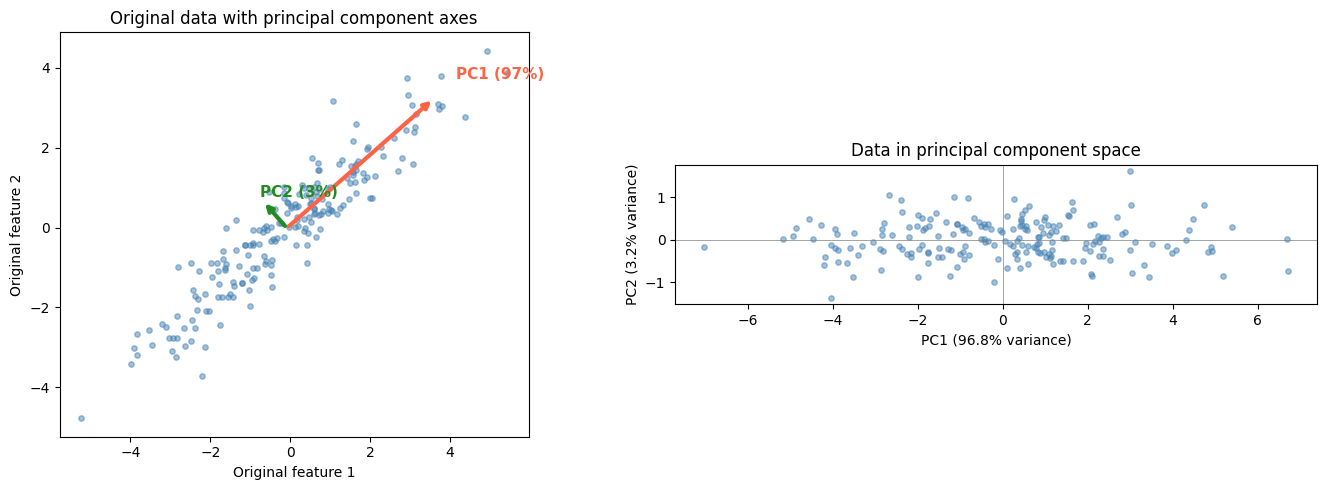

PC1 captures 96.8% of the variance
PC2 captures 3.2% of the variance
Together:     100.0%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ── Generate correlated 2-D data ──
np.random.seed(42)
n = 200
x = np.random.normal(0, 2, n)
y = 0.8 * x + np.random.normal(0, 0.6, n)
X = np.column_stack([x, y])

# ── Fit PCA ──
pca = PCA(n_components=2)
pca.fit(X)

# ── Visualize ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: original data with PC axes
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.5, color='steelblue')
ax.set_xlabel('Original feature 1')
ax.set_ylabel('Original feature 2')
ax.set_title('Original data with principal component axes')
ax.set_aspect('equal')

# Draw PC axes as arrows from the mean
mean = pca.mean_
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    # Scale arrow length by sqrt of eigenvalue for visibility
    length = np.sqrt(var) * 2
    color = 'tomato' if i == 0 else 'forestgreen'
    ax.annotate('', xy=mean + comp * length, xytext=mean,
                arrowprops=dict(arrowstyle='->', color=color, linewidth=3))
    ax.text(mean[0] + comp[0] * length * 1.15,
            mean[1] + comp[1] * length * 1.15,
            f'PC{i+1} ({pca.explained_variance_ratio_[i]:.0%})',
            fontsize=11, fontweight='bold', color=color)

# Right: data projected onto PCs
X_pca = pca.transform(X)
ax = axes[1]
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=15, alpha=0.5, color='steelblue')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Data in principal component space')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"PC1 captures {pca.explained_variance_ratio_[0]:.1%} of the variance")
print(f"PC2 captures {pca.explained_variance_ratio_[1]:.1%} of the variance")
print(f"Together:     {pca.explained_variance_ratio_.sum():.1%}")


The red arrow (PC1) points along the direction of maximum spread. The green arrow (PC2) is perpendicular and captures the remaining variation. In the right panel, the data has been rotated so that the PCs are the new axes — notice that most of the spread is along PC1.

If we only kept PC1, we would go from 2 dimensions to 1 dimension while retaining most of the information. **That's dimensionality reduction.**


## 4. How PCA Works (Conceptual)

PCA involves three steps:

**Step 1 — Center the data:** Subtract the mean of each feature so the data is centered at the origin.

**Step 2 — Compute the covariance matrix:** This matrix captures how every pair of features varies together. Diagonal entries are variances; off-diagonal entries are covariances.

**Step 3 — Find the eigenvectors and eigenvalues:** The eigenvectors of the covariance matrix define the directions of the principal components. The eigenvalues tell you how much variance each component explains.

The eigenvector with the largest eigenvalue is PC1, the next largest is PC2, and so on.

### Key terminology

| Term | Meaning |
|---|---|
| **Principal component (PC)** | A new axis — a linear combination of the original features |
| **Loading** | The weight of each original feature in a PC |
| **Eigenvalue** | The variance explained by a PC |
| **Explained variance ratio** | Fraction of total variance captured by a PC |
| **Scree plot** | Bar/line chart of eigenvalues — helps decide how many PCs to keep |


## 5. PCA in Practice: The Iris Dataset

The Iris dataset has 4 features — impossible to visualize directly in a single plot. PCA can compress it to 2-D while preserving most of the information.


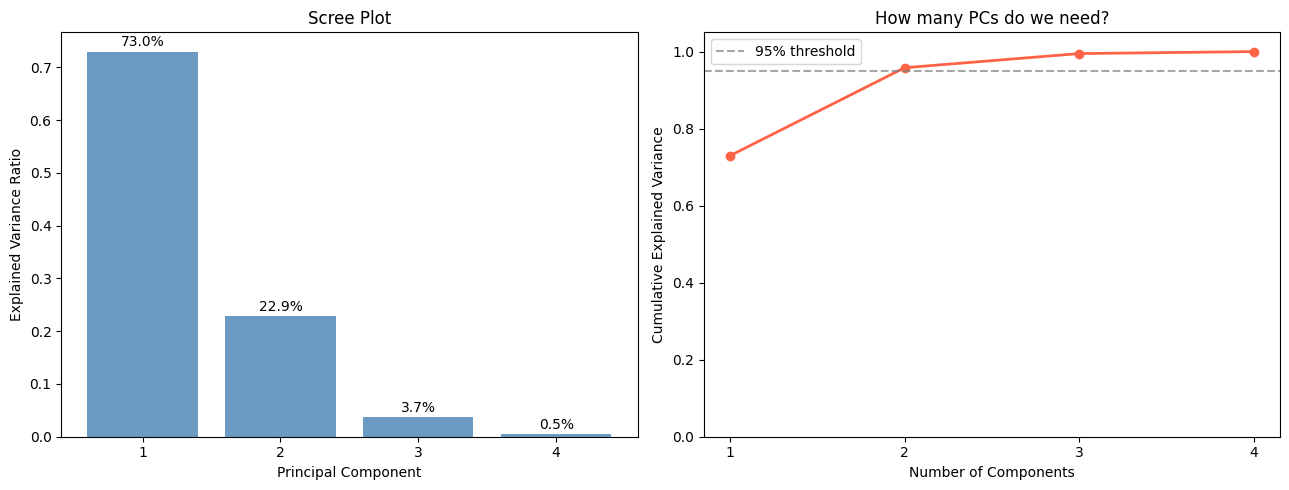

Explained variance per PC: [0.73  0.229 0.037 0.005]
Cumulative: [0.73  0.958 0.995 1.   ]


In [ ]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Load and standardize ──
iris = load_iris()
X = iris.data
y = iris.target

# Always standardize before PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Fit PCA ──
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# ── Scree plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: explained variance per component
axes[0].bar(range(1, 5), pca.explained_variance_ratio_, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, 5))
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i + 1, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# Right: cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, 5), cumvar, 'o-', color='tomato', linewidth=2)
axes[1].axhline(0.95, color='gray', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('How many PCs do we need?')
axes[1].set_xticks(range(1, 5))
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Explained variance per PC:", pca.explained_variance_ratio_.round(3))
print("Cumulative:",  cumvar.round(3))


PC1 and PC2 together capture ~95% of the total variance in the 4-D Iris dataset. This means we can visualize the data in 2-D and lose only ~5% of the information.


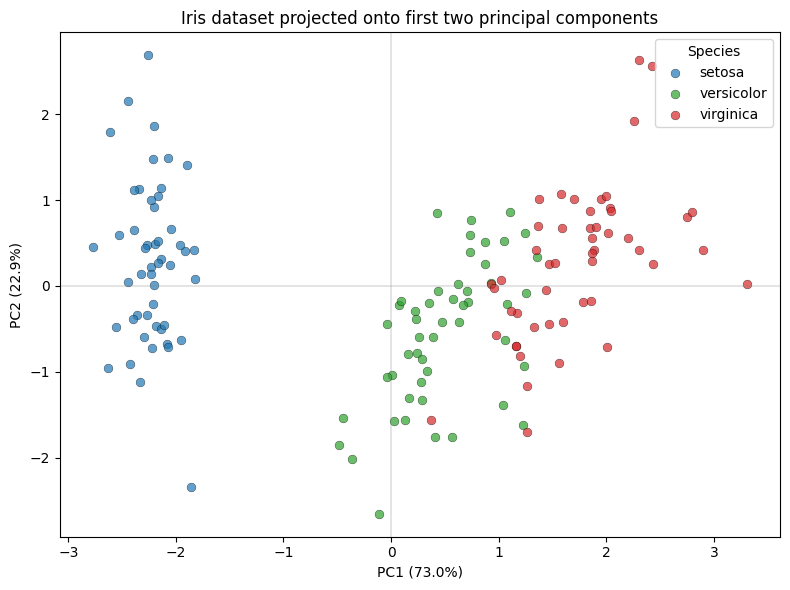

In [ ]:
# ── 2-D PCA scatter plot of Iris ──
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1f77b4', '#2ca02c', '#d62728']
species = iris.target_names

for i, (name, color) in enumerate(zip(species, colors)):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=40,
               alpha=0.7, edgecolors='k', linewidths=0.3, label=name)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Iris dataset projected onto first two principal components')
ax.legend(title='Species')
ax.axhline(0, color='gray', linewidth=0.3)
ax.axvline(0, color='gray', linewidth=0.3)
plt.tight_layout()
plt.show()


Even though PCA is **unsupervised** (it never sees the species labels), the three species naturally separate in PC space. *Setosa* is clearly distinct; *versicolor* and *virginica* overlap somewhat — consistent with what we saw using supervised methods.


## 6. Biplots: Interpreting What the PCs Mean

A PCA scatter plot tells you *where* the data points are, but not *why*. A **biplot** adds the **loading vectors** — arrows showing how each original feature contributes to the PCs.

- A long arrow means that feature strongly influences the PCs.
- The direction of the arrow tells you which PC(s) it loads onto.
- Arrows pointing in similar directions indicate correlated features.


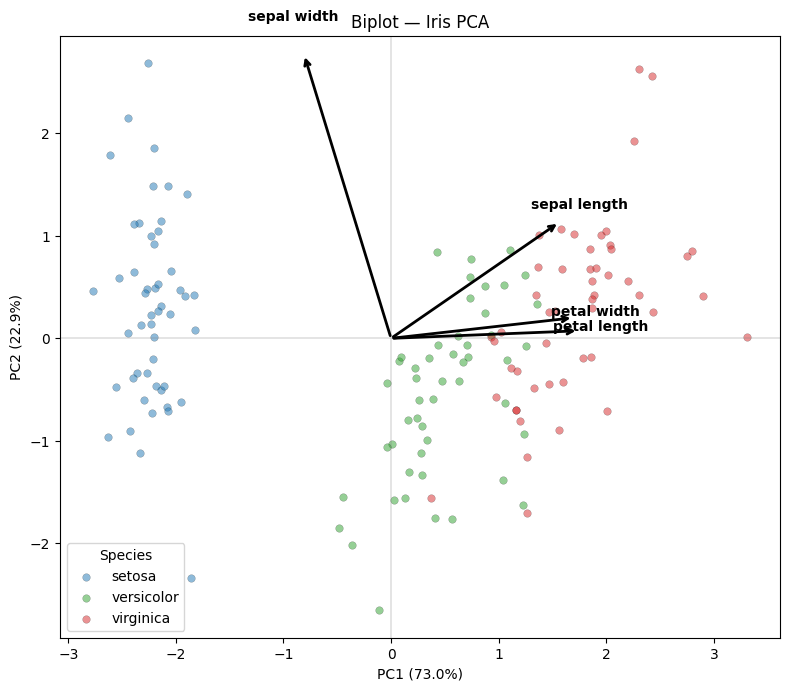

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

# Data points
for i, (name, color) in enumerate(zip(species, colors)):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=30,
               alpha=0.5, edgecolors='k', linewidths=0.2, label=name)

# Loading vectors
loadings = pca.components_[:2].T  # shape: (4 features, 2 PCs)
feature_names = iris.feature_names
scale = 3  # scale arrows for visibility

for j, fname in enumerate(feature_names):
    ax.annotate('', xy=(loadings[j, 0] * scale, loadings[j, 1] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', linewidth=2))
    ax.text(loadings[j, 0] * scale * 1.12,
            loadings[j, 1] * scale * 1.12,
            fname.replace(' (cm)', ''),
            fontsize=10, fontweight='bold', ha='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Biplot — Iris PCA')
ax.legend(title='Species', loc='lower left')
ax.axhline(0, color='gray', linewidth=0.3)
ax.axvline(0, color='gray', linewidth=0.3)
plt.tight_layout()
plt.show()


**How to read this biplot:**

- Petal length and petal width point strongly to the right → they dominate **PC1**. This means PC1 is essentially a "flower size" axis: large petals on the right, small petals on the left.
- Sepal width points upward → it contributes most to **PC2**.
- Petal length and petal width arrows are nearly parallel → these features are highly correlated.
- Sepal width points in a very different direction from petal length → they carry independent information.

> **Ecological interpretation:** PCA doesn't just compress data — it reveals *which variables drive the main patterns of variation*. In community ecology, the loadings might tell you that the first axis is a moisture gradient and the second is a disturbance gradient.


## 7. Combining PCA and K-Means

PCA and K-Means are a powerful pair:

1. **PCA reduces dimensions** → makes K-Means faster and avoids the curse of dimensionality.
2. **PCA provides a 2-D view** → you can actually *see* the clusters that K-Means finds.

Let's demonstrate with the Covertype dataset (54 features — impossible to visualize directly).


Original dimensions: 54
PC1 + PC2 explained variance: 12.6%


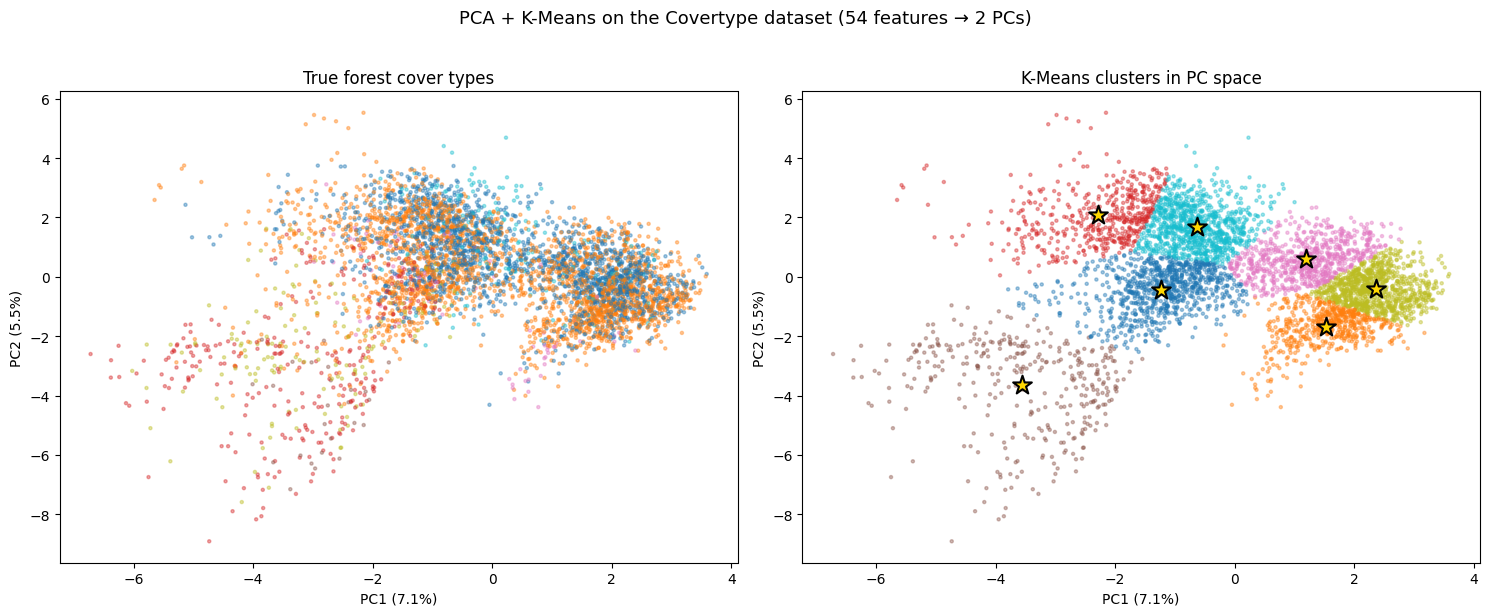

In [ ]:
from sklearn.datasets import fetch_covtype
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# ── Load and subsample ──
covtype = fetch_covtype()
rng = np.random.RandomState(42)
idx = rng.choice(len(covtype.data), size=5000, replace=False)
X_cov = covtype.data[idx]
y_cov = covtype.target[idx]

# ── Standardize and run PCA ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cov)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_cov.shape[1]}")
print(f"PC1 + PC2 explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# ── K-Means in PC space ──
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_pca)

# ── Plot ──
cover_names = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
               "Cottonwood", "Aspen", "Douglas-fir", "Krummholz"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: true labels
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_cov, cmap='tab10',
                          s=5, alpha=0.4)
axes[0].set_title('True forest cover types')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Right: K-Means clusters
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='tab10',
                s=5, alpha=0.4)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='gold', s=200, marker='*', edgecolors='k', linewidths=1.5, zorder=5)
axes[1].set_title('K-Means clusters in PC space')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.suptitle('PCA + K-Means on the Covertype dataset (54 features → 2 PCs)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Even with only 2 PCs (capturing a fraction of the total variance from 54 features), the combination of PCA for visualization and K-Means for clustering reveals spatial structure in the data. The K-Means clusters roughly correspond to groups of forest types — though the correspondence is imperfect because 2 PCs don't capture all the information needed to distinguish 7 cover types.

> **Practical workflow:** For your final projects, try PCA first to explore your data visually, then decide whether to use the PCs as inputs to a classifier or to cluster on them.


## 8. Ecological Application: PCA on Landsat Spectral Bands

Landsat 8 has 6 reflectance bands. Many of these are correlated (e.g., Red and Green). PCA can compress the 6 bands into 2–3 components that capture most of the spectral information — useful for visualization, classification, and change detection.


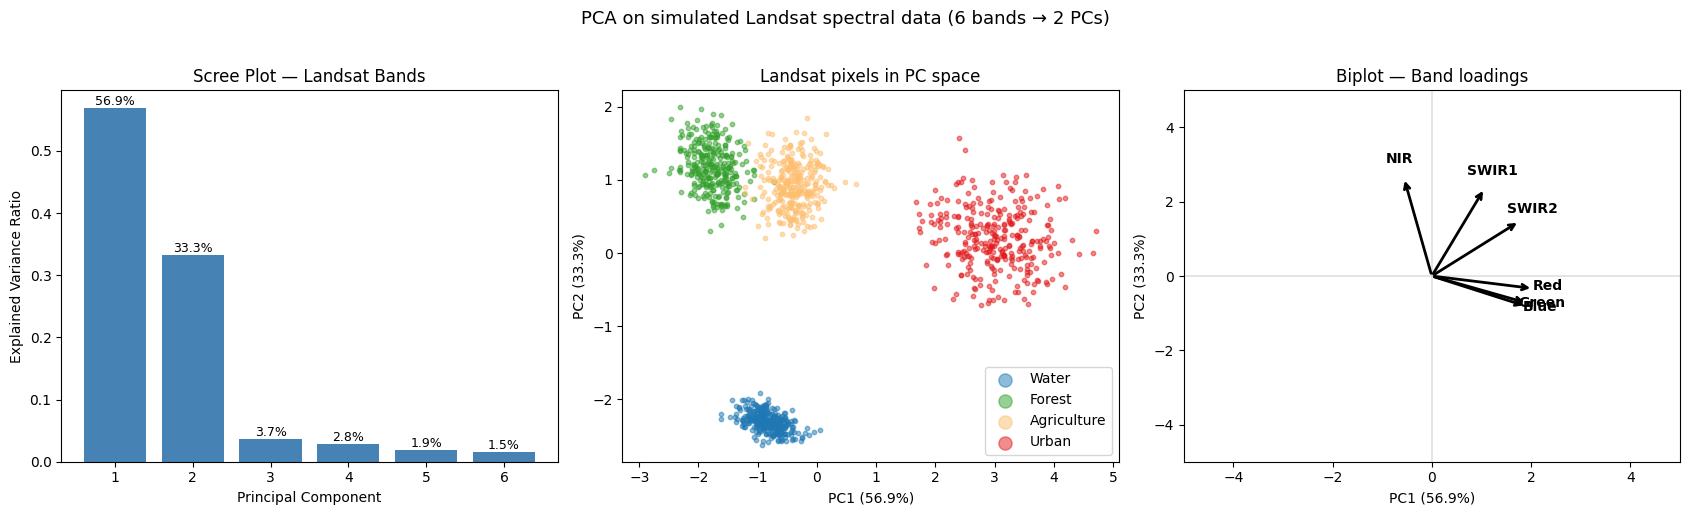

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# ── Simulate Landsat-like data for 4 land-cover types ──
n = 300
band_names = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']

water = np.random.normal([800, 900, 700, 400, 200, 150], [100]*6, (n, 6))
forest = np.random.normal([500, 600, 400, 3500, 1800, 800], [100, 100, 100, 400, 300, 150], (n, 6))
agriculture = np.random.normal([700, 800, 650, 2800, 2200, 1200], [100]*3 + [350, 350, 200], (n, 6))
urban = np.random.normal([1200, 1300, 1400, 1800, 2500, 2200], [200]*3 + [300, 400, 350], (n, 6))

X_landsat = np.vstack([water, forest, agriculture, urban])
y_landsat = np.array([0]*n + [1]*n + [2]*n + [3]*n)
class_names = ['Water', 'Forest', 'Agriculture', 'Urban']
class_colors = ['#1f78b4', '#33a02c', '#fdbf6f', '#e31a1c']

# ── Standardize and PCA ──
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_landsat)

pca = PCA()
X_pca = pca.fit_transform(X_sc)

# ── Scree plot ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].bar(range(1, 7), pca.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot — Landsat Bands')
axes[0].set_xticks(range(1, 7))
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i + 1, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

# ── PC1 vs PC2 scatter ──
for i, (name, color) in enumerate(zip(class_names, class_colors)):
    mask = y_landsat == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=10,
                    alpha=0.5, label=name)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Landsat pixels in PC space')
axes[1].legend(markerscale=3)

# ── Biplot arrows ──
loadings = pca.components_[:2].T
scale = 4
for j, bname in enumerate(band_names):
    axes[2].annotate('', xy=(loadings[j, 0]*scale, loadings[j, 1]*scale),
                     xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='black', linewidth=2))
    axes[2].text(loadings[j, 0]*scale*1.15, loadings[j, 1]*scale*1.15,
                 bname, fontsize=10, fontweight='bold', ha='center')

axes[2].axhline(0, color='gray', linewidth=0.3)
axes[2].axvline(0, color='gray', linewidth=0.3)
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[2].set_title('Biplot — Band loadings')
axes[2].set_xlim(-5, 5)
axes[2].set_ylim(-5, 5)

plt.suptitle('PCA on simulated Landsat spectral data (6 bands → 2 PCs)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Interpreting the Landsat biplot:**

- **PC2** separates vegetation (high NIR, moderate SWIR) from non-vegetation (water and urban). NIR and SWIR1 load strongly on PC1. This is essentially a "greenness" axis.
- **PC1** may separate water (low everything) from urban/bare soil (high visible and SWIR). The visible bands (Blue, Green, Red) contribute here.
- The visible bands cluster together (they are correlated), and NIR points in a distinct direction — consistent with well-known spectral behavior of land surfaces.

## 9. PCA as a Preprocessing Step for Classification

PCA can improve classification performance by:

1. **Removing noise:** Lower-variance PCs often capture noise rather than signal. Discarding them can help.
2. **Reducing multicollinearity:** Correlated features become uncorrelated PCs — some classifiers (e.g., Naive Bayes) benefit from this.
3. **Speeding up training:** Fewer features = faster algorithms (especially KNN and SVM).

Let's compare classification accuracy on the full Iris features vs. PCA-reduced features:


In [ ]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

iris = load_iris()
X_full = StandardScaler().fit_transform(iris.data)
y = iris.target

# PCA to 2 components
X_2pc = PCA(n_components=2).fit_transform(X_full)

classifiers = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Gaussian NB": GaussianNB(),
    "SVM (RBF)":  SVC(kernel="rbf"),
}

print(f"{'Classifier':<20s}  {'4 features':>12s}  {'2 PCs':>12s}")
print("-" * 48)

for name, clf in classifiers.items():
    score_full = cross_val_score(clf, X_full, y, cv=5).mean()
    score_pca  = cross_val_score(clf, X_2pc, y, cv=5).mean()
    print(f"{name:<20s}  {score_full:>11.3f}  {score_pca:>11.3f}")


Classifier              4 features         2 PCs
------------------------------------------------
KNN (k=5)                   0.960        0.913
Gaussian NB                 0.953        0.893
SVM (RBF)                   0.967        0.913


On the Iris dataset, compressing from 4 features to 2 PCs causes only a small accuracy drop — because the first 2 PCs capture ~95% of the variance. In datasets with many more redundant features, PCA can actually *improve* accuracy by removing noisy dimensions.

### When to use PCA for preprocessing

| Situation | PCA helps? |
|---|---|
| Many correlated features (spectral bands, climate variables) | Yes — reduces redundancy |
| KNN or K-Means on high-dimensional data | Yes — mitigates curse of dimensionality |
| Tree-based methods (Random Forest, XGBoost) | Usually not — trees handle high dimensions and correlations natively |
| You need to interpret individual features (e.g., "which band matters?") | Be careful — PCs are mixtures of original features |


## 10. Common Pitfalls

**1. Forgetting to standardize.** PCA finds directions of maximum *variance*. If one feature has a much larger range (e.g., elevation in meters vs. temperature in °C), it will dominate PC1 simply because of its units, not because it's more informative. **Always standardize before PCA** unless your features are already on the same scale.

**2. Over-interpreting small PCs.** Later PCs explain very little variance and may just be noise. Don't try to assign ecological meaning to PC5 if it explains 2% of the variance.

**3. PCA assumes linear relationships.** PCA finds linear combinations of features. If the main pattern in your data is nonlinear (e.g., a curved gradient), PCA may need more components to capture it. For nonlinear dimensionality reduction, look into t-SNE or UMAP (beyond this course, but worth knowing about).

**4. PCs are not always interpretable.** Sometimes PC1 is clearly a "size" or "greenness" axis. Other times the loadings are a complex mix that defies simple interpretation. That's OK — PCA is still useful for compression even when interpretation is difficult.

**5. High variance does not always mean high importance.** PCA finds directions of maximum *variance*, but variance and *relevance* are not always the same thing. Imagine a car-buying dataset where one feature is "number of times the previous owner sang in the car." This might have enormous variance, but it's completely irrelevant to your decision. PCA would rank it highly because it varies a lot — even though it's meaningless.

In environmental data, this can happen with features like sensor ID numbers, arbitrary plot codes, or sampling dates encoded as integers. **Always bring domain knowledge to the interpretation.** PCA tells you *what varies*; you decide *what matters*.


## 11. Summary

| Concept | Key takeaway |
|---|---|
| What PCA does | Finds new axes (PCs) that capture maximum variance in the data |
| PC1 | Direction of greatest variance; PC2 is perpendicular to PC1, etc. |
| Scree plot | Shows how much variance each PC explains; helps decide how many to keep |
| Biplot | Shows both data points and feature loadings — reveals which variables drive each PC |
| Standardize first | Always — otherwise features with larger units dominate |
| PCA + K-Means | PCA reduces dimensions for clustering; provides 2-D visualization of clusters |
| PCA as preprocessing | Can improve KNN/SVM/NB by removing noisy dimensions; less useful for tree methods |
| Limitations | Assumes linear relationships; PCs may be hard to interpret |

### Unsupervised learning recap

| Lecture | Algorithm | What it discovers |
|---|---|---|
| 18 | K-Means | Groups (clusters) in the data |
| **19** | **PCA** | **Dimensions (axes) that capture the most variation** |
